# 解答例（教員用）　第12回
***
> このノートブックは **模範解答の一例**です．コードの空欄（`TODO()`）を埋め，探索は複数ラウンドに分けて実行し，解答欄には実際に得られた出力の数値を根拠に書いています．
> 乱数を使う箇所は固定していますが，ライブラリのバージョンや実行環境によって数値が **小数第2〜3位ほどずれる**ことがあります．探索型の問題なので，**別の探索経路・別の最良設定でも，根拠が筋の通っていれば正解**です．

# 第12回　不均衡データと ROC
***
> **前提**: 第6回の評価指標を発展させ，クラス不均衡への対処と ROC/PR 曲線を学びます。第8回問題4で触れた Precision / Recall / F1 も本回で実践します。

> ⚠️ **この課題で身につけること：コーディングではなく「AI（機械学習）の中身の理解」です。**
>
> コードは AI に書かせても構いません。重要なのは「**なぜその処理を選ぶのか**」「**パラメータや閾値を変えると結果がどう変わるのか**」を理解し、提出物で示すことです。各問には学習目標を示すタグが付いています。
>
> | タグ | 意味 | あなたがすること |
> |---|---|---|
> | **【骨格】** | 動くコードは与えられている | 設計上の決定点（数値・選択肢・特徴量）だけを変更する |
> | **【選択】** | 適切な手法を選ぶ問題 | 複数候補から選び、**理由**を解答用コードセルに書く |
> | **【実験】** | 試行錯誤の記録 | パラメータ等を変えて結果を表に記録し、**考察**する |
> | **【説明】** | 理解の証跡 | 与えられたコードの各行に `# 説明:` で意味を書く |
> | **【探索】** | 最適設定を自分で探す | **仮説 → 試行 → 記録 → 次の仮説** を何度も繰り返す。全試行が自動で履歴に残る |
>
> コードは原則として完成形ですが、**各問の「核心となる最低限の数行」は `# ★あなたが書く★` として空欄**にしてあります（空欄は `TODO()` と書いてあり、そのまま実行すると「空欄が残っています」というエラーで止まります。`TODO()` を自分のコードに書き換えてください）。AI に頼り切らず、要となる処理は自分で書けることも確認します（ボイラープレートは提供済み）。
>
> 各問の **✍️ 解答用コードセル**（`# (1-a)` 形式の変数・文字列）に、設計判断・理由・実験結果・考察を**項目ごとに**記入してください。これが採点対象です。

---

## 🧪 この回の進め方：最適な設定は「自分で」探す

この回では **「正解のパラメータ」は教えません**。答えは、あなたが何度も試して見つけます。

```
  ①仮説を立てる → ②試す（1回1行の記録が自動で残る） → ③結果を見て仮説を直す → ①へ戻る
```

### 試行錯誤の記録帳 `Lab`（最初のコードセルで用意済み。中身を読んで使い方を理解すること）

| 使い方 | 何をするか |
|---|---|
| `lab.df()` | これまでの全試行を表で見る（試行番号・設定・スコア・仮説） |
| `lab.plot(x="threshold", group=...)` | 設定とスコアの関係、ベスト更新の推移をグラフにする |
| `lab.report()` | 探索の自己診断（回数・範囲・端に張り付いていないか・仮説を書いたか） |
| `lab.final_test(...)` | **テストデータでの最終評価。1回しか実行できない** |
| `lab.save()` | 全履歴を CSV に保存する |

### ルール（ここが「AIの理解」の中心）

1. **探索に使ってよいのは検証スコア（訓練データ内で作った予測 = 交差検証の予測）だけ**。テストデータは最後に **1回だけ**（見てから設定を変えたらデータリーク）。
2. **試行のたびに「仮説」を書く**（何を確かめたい試行か）。やみくもな総当たりは評価されません。
3. **粗く → 細かく**：まず桁・範囲を広く振って良さそうな所を掴み、次にその周辺を細かく調べる。
4. **ベストが探索範囲の端に来たら、範囲を広げて確かめる**。
5. 上位の設定同士の差が、ばらつきより小さいなら「差がある」とは言えない。
6. **実験の前に予測を書く**。予測と結果のズレが、あなたが得た「知識」の証拠になる。
7. 最後に、得た知識を **LLM への指示書**にまとめる（最終問題）。

### 評価の観点

| 観点 | 見られること |
|---|---|
| 試行の量と質 | 目安回数以上・仮説が毎回ある・粗→細の流れがある |
| 結果の読み取り | 外れた仮説から何を学んだか（試行番号 `#n` を引用して書く） |
| 検証の作法 | テストは1回だけ／検証スコアとテストの差を正しく解釈している |
| 知識の言語化 | 自分の実験結果を、LLM が実行できる指示書に落とせている |

## 目次
1. 不均衡データの生成
2. class_weight
3. ROC 曲線と AUC
4. 適合率-再現率曲線

---

## この回で学ぶこと

### クラス不均衡が問題になる場面

現実の分類問題では，クラスの数が極端に偏っていることが多い：

| 問題 | クラス比率 |
|---|---|
| クレジットカード不正検知 | 正常 99.8% / 不正 0.2% |
| 医療診断（稀な疾患） | 陰性 99% / 陽性 1% |
| 製品不良品検出 | 良品 99% / 不良品 1% |

このような状況で「全部多数クラスと予測」すると正解率 99.8% になるが，**不正を一件も検知できていない**ので全く役に立たないモデルだ。

### 混同行列（Confusion Matrix）の理解

混同行列は分類モデルの結果を4つの分類で整理する：

```
                予測: Negative  予測: Positive
実際: Negative      TN               FP
実際: Positive      FN               TP
```

- **TP（True Positive）**: 陽性を陽性と正しく予測
- **TN（True Negative）**: 陰性を陰性と正しく予測
- **FP（False Positive）**: 陰性を陽性と誤予測（偽陽性）→ 「誤報」
- **FN（False Negative）**: 陽性を陰性と誤予測（偽陰性）→ 「見逃し」

### 各評価指標の意味

- **適合率（Precision）** = TP / (TP + FP)：「陽性と予測したうち実際に陽性の割合」→ **誤報を減らしたい**時に重視
- **再現率（Recall）** = TP / (TP + FN)：「実際の陽性のうち正しく予測した割合」→ **見逃しを減らしたい**時に重視（医療では特に重要）
- **F1スコア** = 2 × Precision × Recall / (Precision + Recall)：両者の調和平均

### ROC 曲線と AUC

ROC 曲線は**分類閾値を 0〜1 で変化させた時**の「偽陽性率（FPR）vs 真陽性率（TPR）」をプロットしたものだ。

- 完璧なモデル：左上の角に近い曲線
- ランダムな予測：対角線（AUC = 0.5）
- **AUC（Area Under the Curve）**：ROC 曲線の下の面積（0〜1）。1に近いほど良い

### PR 曲線が重要な場面

不均衡データでは ROC 曲線が「楽観的に見える」場合がある（TN が多いため FPR が小さくなりやすい）。**適合率-再現率曲線（PR曲線）** は少数クラスに注目した評価に向いている。

> **卒業研究での指針**: 不均衡データを扱う場合は，正解率だけでなく F1スコア，AUC，PR-AUC を報告することが学術的に求められる。

---

## 📚 将来の自分のためのメモ — 大学研究での応用


### どんな研究で使われるか

| 分野 | 具体例 |
|---|---|
| 医学 | 稀な疾患のスクリーニング，がんの早期発見（陽性が1〜5%） |
| 金融 | クレジット不正，マネーロンダリング検知（正常が99%超） |
| 製造・品質管理 | 不良品検出，設備故障の予兆検知 |
| 情報セキュリティ | 侵入検知，マルウェア分類 |
| 社会科学 | 選挙での少数派支持予測，希少イベントの分析 |

### 応用できる場面

- **少数クラスを見逃すコストが高い**（医療の見逃し，不正の未検知）
- **誤報のコストと見逃しのコストが非対称**（用途によって Precision / Recall の重みが変わる）
- クラス比率が **1:10 以上**に偏っている
- 分類**閾値を業務要件に合わせて調整**したい

### 応用しにくい・向かない場面

- **クラスがほぼ均衡**している → Accuracy でも十分なことが多い
- **回帰問題**（連続値予測）— 本回の指標は分類専用
- **全クラスが同等に重要なマルチクラス分類**（1対多の不均衡対策だけでは不十分）
- ROC-AUC だけを報告して満足する場合（**極端な不均衡では PR 曲線の方が実態を反映**しやすい）
- `class_weight` や SMOTE を適用したら**必ず良くなるとは限らない**— 検証が必要

### 研究で報告するときのポイント

1. **クラス比率**を表で明示する
2. Accuracy に加え **F1，ROC-AUC，PR-AUC（Average Precision）** を併記
3. 採用した**閾値**とその理由（「Recall を 0.9 以上にした」など）
4. 混同行列で **FN（見逃し）と FP（誤報）** のトレードオフを議論

### 関連する発展トピック（調べてみると良い）

- SMOTE，ADASYN（オーバーサンプリング）
- Cost-sensitive learning（誤分類コストの重み付け）
- Calibration（確率出力の信頼性）— 第17回の Overconfidence と関連

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold


# ==== 試行錯誤の記録帳（この回の全実験がここに溜まる。中身を読んで使い方を理解しておくこと）====
class Lab:
    """試行錯誤の記録帳。何回でも log() でき、表・グラフ・診断レポートにできる。
    ・スコア（score）は「検証用スコア（CV など）」だけを記録する。テストデータは final_test() で1回だけ。
    ・bounds = {パラメータ名: (下限, 上限)} … それ以上広げられない値（例：k の下限 2）。ベストがここにあっても「端」と警告しない。
    ・ignore = {パラメータ名: [値, ...]} … 範囲の計算から外す特別な値（例：正則化なしを表す alpha=0）。"""

    def __init__(self, name, score_name="cv_score", higher_is_better=True, bounds=None, ignore=None):
        self.name, self.score_name, self.hib = name, score_name, higher_is_better
        self.bounds, self.ignore = bounds or {}, ignore or {}
        self.rows, self.test_result = [], None

    def seen(self, params):
        return any(r["params"] == params for r in self.rows)

    def log(self, hypothesis, params, score, **extra):
        """1試行を記録する。同じ params を再度記録しようとすると無視する（重複の水増し防止）。"""
        if self.seen(params):
            print(f"  (skip) 既に試した設定です: {params}")
            return
        self.rows.append(dict(trial=len(self.rows) + 1, hypothesis=hypothesis.strip(),
                              params=dict(params), score=float(score), extra=extra))
        best = self.best()["trial"] == len(self.rows)
        print(f"  #{len(self.rows):02d} {params}  {self.score_name}={score:.4f}"
              + "".join(f"  {k}={v}" for k, v in extra.items()) + ("  ★ベスト更新" if best else ""))

    def df(self):
        import pandas as pd
        return pd.DataFrame([{"trial": r["trial"], **r["params"], self.score_name: round(r["score"], 4),
                              **r["extra"], "hypothesis": r["hypothesis"]} for r in self.rows])

    def best(self):
        return (max if self.hib else min)(self.rows, key=lambda r: r["score"])

    def plot(self, x, group=None, logx=True, query=None):
        """パラメータ x とスコアの関係（group ごとに線を分ける）と、試行回数ごとのベスト更新の推移。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        import matplotlib.pyplot as plt
        d = self.df()
        dd = d.query(query) if query else d
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
        for g, sub in (dd.groupby(group) if group else [("all", dd)]):
            sub = sub.sort_values(x)
            ax[0].plot(sub[x], sub[self.score_name], "o-", label=str(g))
        if logx and dd[x].dtype.kind in "if" and (dd[x] > 0).all(): ax[0].set_xscale("log")
        ax[0].set_xlabel(x); ax[0].set_ylabel(self.score_name); ax[0].legend(); ax[0].set_title("Parameter vs. validation score")
        cur = d[self.score_name].cummax() if self.hib else d[self.score_name].cummin()
        ax[1].step(d["trial"], cur, where="post"); ax[1].plot(d["trial"], d[self.score_name], "x", alpha=.5)
        ax[1].set_xlabel("Trial number"); ax[1].set_title("Best score so far (flat = plateau)")
        plt.tight_layout(); plt.show()

    def report(self, min_trials=15):
        """探索の質の自己診断：回数・カバー範囲・端に張り付いていないか・仮説を書いたか。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        d, n = self.df(), len(self.rows)
        print(f"■ 試行回数: {n}（目安 {min_trials} 回以上） → {'OK' if n >= min_trials else 'まだ足りない'}")
        keys = list(self.rows[0]["params"]) if n else []
        b = self.best()
        print(f"■ ベスト: trial#{b['trial']} {b['params']}  {self.score_name}={b['score']:.4f}")
        for k in keys:
            vals = [r["params"][k] for r in self.rows if r["params"][k] not in self.ignore.get(k, [])]
            uniq = sorted(set(map(str, vals)))
            line = f"■ {k}: {len(uniq)} 種類を試した"
            nums = [v for v in vals if isinstance(v, (int, float)) and not isinstance(v, bool)]
            if k != "seed" and vals and len(nums) == len(vals) and len(set(nums)) > 2:
                lo, hi = min(nums), max(nums)
                blo, bhi = self.bounds.get(k, (None, None))
                bv = b["params"][k]
                edge = (bv == lo and lo != blo) or (bv == hi and hi != bhi)
                line += f"（範囲 {lo:g}〜{hi:g}）" + (" ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう" if edge else "")
            print(line)
        w = sum(1 for r in self.rows if len(r["hypothesis"]) >= 8)
        print(f"■ 仮説を書いた試行: {w}/{n}" + ("" if w == n else " ⚠ 何を確かめる試行か毎回書こう"))
        if n >= 6:
            third = n // 3
            print(f"■ 前半の最高 {d[self.score_name][:third].max():.4f} → 後半の最高 {d[self.score_name][-third:].max():.4f}")

    def final_test(self, score_fn, name="最終テストスコア", compare=True):
        """テストデータでの最終評価。1回しか実行できない（2回目以降はエラー）。
        compare=False は、検証スコアと別の指標で評価するとき（並べて比べられないので表示しない）。"""
        if self.test_result is not None:
            raise RuntimeError(f"テストは既に使用済みです（結果 {self.test_result:.4f}）。テストを見て設定を変えるのはデータリークです。")
        self.test_result = float(score_fn())
        print(f"{name} = {self.test_result:.4f}"
              + (f"   （検証ベスト {self.score_name} = {self.best()['score']:.4f}）" if compare else ""))
        return self.test_result

    def save(self, path=None):
        path = path or f"{self.name}_log.csv"
        self.df().to_csv(path, index=False, encoding="utf-8-sig"); print("保存:", path)


def TODO():
    """「★あなたが書く★」の空欄。自分のコードに置き換えるまで、実行するとここで止まる。"""
    raise NotImplementedError("★あなたが書く★ の空欄（TODO()）がまだ残っています。自分のコードに書き換えてから再実行してください。")


## 問題1　不均衡データの生成と確認　【骨格+選択】
***

### `make_classification` のパラメータ解説

`make_classification` は人工的な分類データを生成する。今回のパラメータ：
- `n_samples=5000`：5000件のデータ
- `n_features=20`：20個の特徴量（うち役に立つのは `n_informative=5` 個、`n_redundant=2` 個は他の特徴量の組合せ、残りはノイズ）
- `class_sep=1.0`：クラスの分離しやすさ（**大きいほど分けやすい**）。1.0 は「そこそこ分けられるが、閾値の選び方しだいで見逃しも誤報も出る」程度の難しさ。0.7 まで下げると重なりが大きすぎて、Recall 0.80 を確保すると Precision が 0.1〜0.15（陽性と言った 10 件中 9 件が誤報）にしかならず、どの設定でも「ほぼ使えない」結果になる。逆に 1.5 以上ではどの設定でも Precision 0.9 以上になり、工夫の差が見えなくなる
- `weights=[0.95, 0.05]`：**クラス0が95%，クラス1が5%** という不均衡設定
- `random_state=0`：再現性のため固定

### 不均衡度の確認が最初のステップ

データを受け取ったら，まず**クラスの分布を確認**することが重要だ。不均衡比率によって対処法が変わる：
- まず試すのは，**少数クラスの重みを上げる**（`class_weight`）ことと，**決定閾値を動かす**ことの2つ。どちらも追加のライブラリが要らず，今回のデータ（約 17:1）でも効果を確かめられる（問題2）
- オーバーサンプリング（SMOTE）やアンダーサンプリングは，極端な不均衡（100:1 以上など）で候補になる。ただし重み付け・閾値調整より常に良いとは限らないので，**同じ検証方法で比べてから**採用する

### 課題

下のコードセルは、不均衡データの生成とクラス分布の表示を用意してありますが、**核心（train/test 分割）はあなたが書きます**（`# ★あなたが書く★`）。まずは `minority_ratio = 0.05` のまま実行し、どれだけ偏ったデータかを確認してください。`minority_ratio`・`class_sep`（★印の行）を変えれば不均衡の度合いや分けやすさを変えられます（`class_sep` を大きくしすぎると、どんな設定でも見逃しがほぼ出ず、問題2の実験の差が見えなくなります）。

ここで生成したデータ（`X_train, X_test, y_train, y_test`）は問題2以降でそのまま使います。

そのうえで、次の **設計判断** に答えてください。

> **設計判断（不均衡への対処を選ぶ）**: このデータで「**陽性（クラス1＝不正/疾患など）の見逃し（FN）を絶対に減らしたい**」という状況だとします。次の対処から**1つ選び、理由**を解答用コードセルに書いてください。選んだ方針は問題2の実験につながります。
>
> - **(A) 何もしない**（そのまま `LogisticRegression` を学習）
> - **(B) `class_weight="balanced"`** … 少数クラスの誤分類のペナルティを大きくする
> - **(C) 決定閾値を下げる** … `predict_proba` のしきい値を 0.5 より小さくして陽性判定を増やす
> - **(D) オーバーサンプリング（SMOTE 等）** … 少数クラスを人工的に増やしてクラス比を是正
> - **(E) アンダーサンプリング** … 多数クラスを間引いてクラス比を是正
> - **(F) 決定閾値を上げる（0.5→0.7）** … 陽性判定を厳しくする
>
> ヒント：「見逃しを減らしたい＝Recall を上げたい」とき、どの対処が直接効くでしょうか。逆効果になる選択肢も混ざっています（例えば (F) は見逃しを増やす方向です）。**やみくもに全部やる**のではなく、**この状況に合うもの**を選び、なぜ効くと思うかを書いてください（複数挙げてもよいが主役を1つ）。


In [2]:
# === 完成済みコード：実行して不均衡の度合いを確認してください ===
# === ★ここを変えて実験する★：少数クラス（クラス1）の比率（まずは 0.05 のまま実行）===
minority_ratio = 0.05
# === ★ここも変えられる★：クラスの分離しやすさ（小さいほど難しい。0.5〜1.5 程度で試せる）===
CLASS_SEP = 1.0

X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    class_sep=CLASS_SEP,
    weights=[1 - minority_ratio, minority_ratio],
    random_state=0,
)
# ★あなたが書く★：X, y を train/test に 8:2 で分割する（1行。stratify=y で不均衡比率を保つ）
#   ヒント: train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

counts = pd.Series(y_train).value_counts().sort_index()
ratio = (counts / counts.sum() * 100).round(1)
dist = pd.concat([counts.rename("件数"), ratio.rename("比率%")], axis=1)
dist.index.name = "クラス"
print("訓練データのクラス分布:")
print(dist)


訓練データのクラス分布:
       件数   比率%
クラス            
0    3779  94.5
1     221   5.5


In [3]:
# === データの中身を確認する（実行するだけ。コードは変更しない）===
print("X_train の形:", X_train.shape, "（件数, 特徴量数）")
print("先頭 3 件の最初の 5 特徴量:")
print(pd.DataFrame(X_train[:3, :5]).round(2))
print("先頭 30 件のラベル y_train:", y_train[:30], "  ← 1 が少数クラス（陽性）")

X_train の形: (4000, 20) （件数, 特徴量数）
先頭 3 件の最初の 5 特徴量:
      0     1     2     3     4
0  2.07 -1.04 -0.10  0.28 -0.15
1 -0.60  0.15  1.89 -0.87 -0.33
2 -0.59  0.32  0.84 -1.07  0.40
先頭 30 件のラベル y_train: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]   ← 1 が少数クラス（陽性）


In [4]:
# === ✍️ 問題1 解答（採点対象）===

# (1-a) 観察：訓練データのクラス0／クラス1の件数と比率
observation_1_a = """
訓練データ 4000 件：クラス0 = 3779 件（94.5%）、クラス1 = 221 件（5.5%）。約 17 : 1 の不均衡。「全部クラス0と予測」するだけで正解率 0.945 になる。
"""

# (1-b) 設計判断：見逃し（FN）を減らしたい状況で選んだ対処（A〜F）：(　)
# (A) 何もしない（そのまま LogisticRegression を学習）
# (B) class_weight="balanced"（少数クラスの誤分類のペナルティを大きくする）
# (C) 決定閾値を下げる（陽性判定を増やす）
# (D) オーバーサンプリング（SMOTE 等）
# (E) アンダーサンプリング（多数クラスを間引く）
# (F) 決定閾値を上げる（0.5→0.7）
design1_choice = "C"
# (1-c) その理由（なぜこの状況に合うか／なぜ見逃しを減らせると思うか）
answer_1_c = """
(C) 決定閾値を下げる。見逃し（FN）を減らす＝Recall を上げたいので、陽性の確率が 0.5 未満でも陽性と判定する範囲を広げるのが最も直接的で、モデルの再学習も要らない。(F) 閾値を上げるのは逆効果、(A) 何もしないのは見逃しが多い。(B) class_weight も Recall を上げる方向に働くが、係数自体が変わる分、効果が閾値ほど直接でない。(D)(E) のサンプリングは 17 : 1 程度ならまず不要。まず閾値で試し、足りなければ (B) を併用しようと考えた。
"""



## 問題2　「見逃しを減らす」最適設定を自分で探す　【探索】
***

### 課題設定：目的を「制約つきの最適化」に翻訳する

問題1で「陽性の見逃し（FN）を減らしたい」と考えました。でも「見逃しを減らす」だけなら **全員を陽性と予測すれば見逃しゼロ**です（Precision は最悪）。現実の依頼は次のような形になります：

> **Recall（見逃さない割合）が 0.80 以上という条件を満たしたうえで、Precision（陽性と言った中の的中率）を最大にする設定を見つけよ。**

この「制約つきの目的」を数値にしたのが下の `objective`（探索の物差し）です。

```
objective = Precision   （Recall ≥ 0.80 のとき）
          = Recall - 0.80（Recall < 0.80 のとき。負の値＝制約違反）
```

### 探す軸

| 軸 | 意味 | 注意点 |
|---|---|---|
| `pos_weight` | クラス1（陽性）の誤りを何倍重く扱うか（1=何もしない）。`class_weight="balanced"` は陰性:陽性の件数比に相当（**このデータでは約 17**。下の「経過の確認」の前に `n_neg / n_pos` を表示する） | 大きいほど陽性を見逃しにくいが Precision が落ちる |
| `threshold` | 決定閾値（`proba >= threshold` で陽性）。標準は 0.5 | 下げると陽性判定が増える |
| `C` | 正則化の強さ（大きいほど弱い）。第9回の内容 | 影響は小さいかもしれない。**確かめるのも探索** |

`pos_weight` を上げる方法と `threshold` を下げる方法は、**似た効果**があるでしょうか？ それとも違うでしょうか？ 実験で確かめてください。

### 検証の作法

探索では訓練データ内で「交差検証の予測」（`cross_val_predict`）を作って評価します。テストデータ（`X_test`）は最終評価の **1回だけ**。

### 課題

1. **【実験前に先に書く】** 下の予測セルに、`pos_weight` と `threshold` のどちらが効くか、最良設定の予測と理由を書く。
2. 探索セルの `hypothesis` と `settings` を書き換えて何度も実行（**15回以上**）。**核心2つ（OOF 確率の作成・閾値での 0/1 化）はあなたが書きます**。
3. 経過確認セルで、制約（Recall≥0.80）を満たす設定の中で頭打ち・端に張り付いていないかを見る。
4. 最終評価セルを **1回だけ**実行する。
5. 解答セルに書く。

> **Precision の値の読み方**: 陽性は全体の約 5.5% なので、でたらめに「陽性」と言っても Precision は約 0.055 です。Recall を 0.80 まで上げたときに Precision がいくつ残るか（この何倍か）が、モデルの実力です。
>
> **考察1**: 何もしない設定（`pos_weight=1, threshold=0.5`）の Precision・Recall と FN 件数は？ そこから何を変えると Recall が上がり、Precision はどう動きましたか？
>
> **考察2（トレードオフ）**: なぜ Recall を上げると Precision が下がるのか、混同行列の TP・FP・FN の動きに触れて説明してください。
>
> **考察3（重みと閾値）**: `pos_weight` を上げる方法と `threshold` を下げる方法で、同じ Recall のときの Precision はどちらが高かったですか？ 差は意味のある大きさでしたか？
>
> **考察4**: 問題1で選んだ対処は、この目的（Recall≥0.80 で Precision 最大）に対して最良でしたか？

In [5]:
# === ✍️ 問題2-0 実験前の予測（実験を始める前に書く。実験後に書き直さない）===

# 目的（Recall>=0.80 で Precision 最大）に、より効くと思うのはどちらか（"pos_weight" / "threshold" / "ほぼ同じ"）
prediction_2_which = "threshold"
# 最良だと思う (pos_weight, threshold)
prediction_2_best = (5, 0.2)
# そう予測した理由（知識・直感・LLMの回答など。LLMに聞いた場合は回答を貼り、自分との違いも書く）
prediction_2_reason = """
閾値を下げる方が直接 Recall に効き、class_weight は間接的だと考えた。陽性が 5% なので 0.5 のままでは確率がほとんど 0.5 を超えず、Recall 0.8 には閾値 0.2 前後が必要だと予想した。C の影響はほとんど無いと思った。
"""

In [6]:
# === 完成済みコード（★の箇所だけ自分で書く）：試す → lab に記録、を繰り返せる形になっている ===
# 問題1 で作った X_train / X_test / y_train / y_test を使う。X_test は最終評価まで一切使わない
n_neg, n_pos = int((y_train == 0).sum()), int((y_train == 1).sum())
print(f"陰性:陽性 = {n_neg}:{n_pos}（比 {n_neg / n_pos:.1f}）→ class_weight='balanced' は pos_weight ≈ {n_neg / n_pos:.0f} に相当")
print(f"陽性の比率 = {n_pos / (n_neg + n_pos):.3f}（Precision がこの値なら「でたらめに陽性と言うのと同じ」。これの何倍かで見る）")
RECALL_TARGET = 0.80
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
lab = Lab("q12_imbalance", score_name="objective", bounds={"pos_weight": (1, None)})
_proba_cache = {}                       # (pos_weight, C) ごとの OOF 確率。閾値だけ変える試行は再計算しない

def objective(prec, rec):
    """Recall が目標を満たせば Precision、満たさなければ（負の）不足分"""
    return prec if rec >= RECALL_TARGET else rec - RECALL_TARGET

def oof_proba(pos_weight, C):
    key = (pos_weight, C)
    if key not in _proba_cache:
        model = LogisticRegression(max_iter=1000, C=C, class_weight={0: 1, 1: pos_weight})
        # ★あなたが書く★：訓練データ内の5分割CVで、各サンプルの「陽性の確率」を求めて返す（1行）
        #   ヒント: cross_val_predict(model, X_train, y_train, cv=cv5, method="predict_proba")[:, 1]
        _proba_cache[key] = cross_val_predict(model, X_train, y_train, cv=cv5, method="predict_proba")[:, 1]
    return _proba_cache[key]

def run_trial(hypothesis, pos_weight, threshold, C):
    """1つの設定を試して lab に記録する（同じ設定は2回記録されない）"""
    params = {"pos_weight": pos_weight, "threshold": threshold, "C": C}
    if lab.seen(params):
        print(f"  (skip) 既に試した設定です: {params}"); return
    proba = oof_proba(pos_weight, C)
    # ★あなたが書く★：予測確率 proba を閾値 threshold で 0/1 に変換して y_pred を作る（1行）
    #   ヒント: (proba >= threshold).astype(int)
    y_pred = (proba >= threshold).astype(int)
    prec = precision_score(y_train, y_pred, zero_division=0)
    rec = recall_score(y_train, y_pred, zero_division=0)
    lab.log(hypothesis, params, objective(prec, rec),
            precision=round(prec, 3), recall=round(rec, 3),
            fn=int(confusion_matrix(y_train, y_pred)[1, 0]))

# === ★ここを変えて実験する★：仮説を書き、settings を書き換えて何度でも実行 ===
# 【変更のしかた】
#  ① hypothesis … 今回の試行で「何を確かめたいか」を1文で書き換える（例：「alpha を10倍にすると CV は上がるはず」）。空・短すぎると report で警告される
#  ② settings   … 試したい設定を「1行に1つのタプル」で並べる。タプルの並び順は (pos_weight, threshold, C)
#       pos_weight … 陽性（クラス1）の誤りを何倍重く扱うか。1 = 何もしない。class_weight="balanced" は陰性:陽性の比（約 17）に相当
#       threshold … 決定閾値。予測確率がこの値以上なら陽性と判定（標準は 0.5、下げると陽性が増える）
#       C … 正則化の強さの逆数（0.01〜100）
#     行を足す／消す／数値を書き換えてよい。例：settings = [(1, 0.5, 1.0), (1, 0.2, 1.0), (1, 0.1, 1.0), (5, 0.5, 1.0), (19, 0.5, 1.0)]
#  ③ 実行すると、この settings の各行が1試行として lab に記録される（前に試した試行は消えず、同じ設定は重複記録されない）
#  ④ 下の「経過の確認」セルで結果を見て、①②を書き換えて再実行する（これを何回も繰り返す）
#  ※ 15 回以上。pos_weight と threshold の両方を動かすこと。
# 進め方の例： ①pos_weight と threshold を別々に動かす → ②制約を満たす所を絞り込む → ③組合せ・C を確認
hypothesis = "何もしない設定を基準に、pos_weight だけ / threshold だけを動かして効き方を比べる"
settings = [                       # (pos_weight, threshold, C)
    (1, 0.5, 1.0),                 # 何もしない（基準）
    (1, 0.2, 1.0), (1, 0.1, 1.0),  # threshold だけ下げる
    (5, 0.5, 1.0), (17, 0.5, 1.0), # pos_weight だけ上げる（17 ≈ balanced）
]
for w, th, C in settings:
    run_trial(hypothesis, w, th, C)

陰性:陽性 = 3779:221（比 17.1）→ class_weight='balanced' は pos_weight ≈ 17 に相当
陽性の比率 = 0.055（Precision がこの値なら「でたらめに陽性と言うのと同じ」。これの何倍かで見る）
  #01 {'pos_weight': 1, 'threshold': 0.5, 'C': 1.0}  objective=-0.2570  precision=0.857  recall=0.543  fn=101  ★ベスト更新
  #02 {'pos_weight': 1, 'threshold': 0.2, 'C': 1.0}  objective=-0.0715  precision=0.652  recall=0.729  fn=60  ★ベスト更新
  #03 {'pos_weight': 1, 'threshold': 0.1, 'C': 1.0}  objective=0.4771  precision=0.477  recall=0.801  fn=44  ★ベスト更新


  #04 {'pos_weight': 5, 'threshold': 0.5, 'C': 1.0}  objective=-0.0805  precision=0.602  recall=0.719  fn=62
  #05 {'pos_weight': 17, 'threshold': 0.5, 'C': 1.0}  objective=0.3126  precision=0.313  recall=0.819  fn=40


In [7]:
hypothesis = "閾値だけで制約を満たした #3（threshold=0.1）の周辺を細かく見て、Precision を残せる境界を探す"
settings = [(1, 0.15, 1.0), (1, 0.12, 1.0), (1, 0.08, 1.0), (1, 0.05, 1.0)]
for w, th, C in settings:
    run_trial(hypothesis, w, th, C)

  #06 {'pos_weight': 1, 'threshold': 0.15, 'C': 1.0}  objective=-0.0443  precision=0.56  recall=0.756  fn=54


  #07 {'pos_weight': 1, 'threshold': 0.12, 'C': 1.0}  objective=-0.0217  precision=0.513  recall=0.778  fn=49
  #08 {'pos_weight': 1, 'threshold': 0.08, 'C': 1.0}  objective=0.3943  precision=0.394  recall=0.81  fn=42
  #09 {'pos_weight': 1, 'threshold': 0.05, 'C': 1.0}  objective=0.2891  precision=0.289  recall=0.837  fn=36


制約（Recall>=0.80）を満たした設定の数: 4 / 9


,trial,pos_weight,threshold,C,objective,precision,recall,fn
2,3,1,0.10,1.0,0.4771,0.477,0.801,44
7,8,1,0.08,1.0,0.3943,0.394,0.810,42
4,5,17,0.50,1.0,0.3126,0.313,0.819,40
8,9,1,0.05,1.0,0.2891,0.289,0.837,36
6,7,1,0.12,1.0,-0.0217,0.513,0.778,49
5,6,1,0.15,1.0,-0.0443,0.560,0.756,54
1,2,1,0.20,1.0,-0.0715,0.652,0.729,60
3,4,5,0.50,1.0,-0.0805,0.602,0.719,62


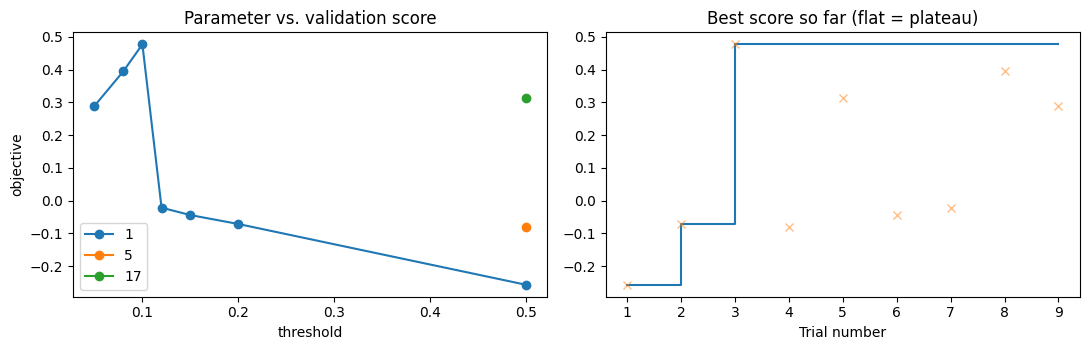

■ 試行回数: 9（目安 15 回以上） → まだ足りない
■ ベスト: trial#3 {'pos_weight': 1, 'threshold': 0.1, 'C': 1.0}  objective=0.4771
■ pos_weight: 3 種類を試した（範囲 1〜17）
■ threshold: 7 種類を試した（範囲 0.05〜0.5）
■ C: 1 種類を試した
■ 仮説を書いた試行: 9/9
■ 前半の最高 0.4771 → 後半の最高 0.3943


In [8]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
d = lab.df()
print("制約（Recall>=%.2f）を満たした設定の数: %d / %d" % (RECALL_TARGET, (d["recall"] >= RECALL_TARGET).sum(), len(d)))
display(d.drop(columns="hypothesis").sort_values("objective", ascending=False).head(8))
lab.plot(x="threshold", group="pos_weight", logx=False)    # threshold と objective、ベスト更新の推移
lab.report(min_trials=15)

In [9]:
hypothesis = "重みと閾値を組み合わせると、閾値だけより Precision が高い所があるか（同じ Recall で比べる）"
settings = [(5, 0.3, 1.0), (5, 0.25, 1.0), (10, 0.4, 1.0), (10, 0.3, 1.0), (17, 0.6, 1.0)]
for w, th, C in settings:
    run_trial(hypothesis, w, th, C)

  #10 {'pos_weight': 5, 'threshold': 0.3, 'C': 1.0}  objective=-0.0081  precision=0.398  recall=0.792  fn=46
  #11 {'pos_weight': 5, 'threshold': 0.25, 'C': 1.0}  objective=0.3390  precision=0.339  recall=0.819  fn=40
  #12 {'pos_weight': 10, 'threshold': 0.4, 'C': 1.0}  objective=0.3346  precision=0.335  recall=0.81  fn=42
  #13 {'pos_weight': 10, 'threshold': 0.3, 'C': 1.0}  objective=0.2537  precision=0.254  recall=0.851  fn=33
  #14 {'pos_weight': 17, 'threshold': 0.6, 'C': 1.0}  objective=-0.0127  precision=0.388  recall=0.787  fn=47


制約（Recall>=0.80）を満たした設定の数: 7 / 14


,trial,pos_weight,threshold,C,objective,precision,recall,fn
2,3,1,0.10,1.0,0.4771,0.477,0.801,44
7,8,1,0.08,1.0,0.3943,0.394,0.810,42
10,11,5,0.25,1.0,0.3390,0.339,0.819,40
11,12,10,0.40,1.0,0.3346,0.335,0.810,42
4,5,17,0.50,1.0,0.3126,0.313,0.819,40
8,9,1,0.05,1.0,0.2891,0.289,0.837,36
12,13,10,0.30,1.0,0.2537,0.254,0.851,33
9,10,5,0.30,1.0,-0.0081,0.398,0.792,46


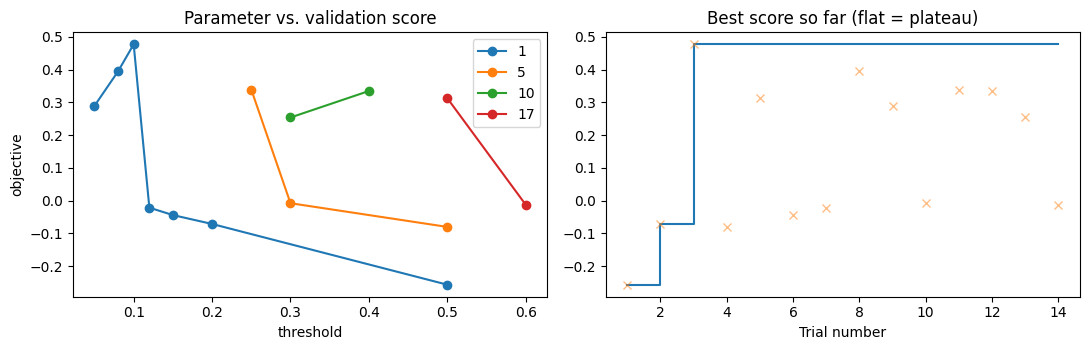

■ 試行回数: 14（目安 15 回以上） → まだ足りない
■ ベスト: trial#3 {'pos_weight': 1, 'threshold': 0.1, 'C': 1.0}  objective=0.4771
■ pos_weight: 4 種類を試した（範囲 1〜17）
■ threshold: 11 種類を試した（範囲 0.05〜0.6）
■ C: 1 種類を試した
■ 仮説を書いた試行: 14/14
■ 前半の最高 0.4771 → 後半の最高 0.3390


In [10]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
d = lab.df()
print("制約（Recall>=%.2f）を満たした設定の数: %d / %d" % (RECALL_TARGET, (d["recall"] >= RECALL_TARGET).sum(), len(d)))
display(d.drop(columns="hypothesis").sort_values("objective", ascending=False).head(8))
lab.plot(x="threshold", group="pos_weight", logx=False)    # threshold と objective、ベスト更新の推移
lab.report(min_trials=15)

In [11]:
hypothesis = "C（正則化の強さ）は結果に影響するか。最良付近で強い/弱い正則化を比べる"
settings = [(1, 0.1, 0.01), (1, 0.1, 100), (1, 0.12, 0.1), (17, 0.5, 0.01)]
for w, th, C in settings:
    run_trial(hypothesis, w, th, C)

  #15 {'pos_weight': 1, 'threshold': 0.1, 'C': 0.01}  objective=-0.0398  precision=0.52  recall=0.76  fn=53
  #16 {'pos_weight': 1, 'threshold': 0.1, 'C': 100}  objective=0.4758  precision=0.476  recall=0.801  fn=44
  #17 {'pos_weight': 1, 'threshold': 0.12, 'C': 0.1}  objective=-0.0262  precision=0.534  recall=0.774  fn=50
  #18 {'pos_weight': 17, 'threshold': 0.5, 'C': 0.01}  objective=0.3339  precision=0.334  recall=0.819  fn=40


制約（Recall>=0.80）を満たした設定の数: 9 / 18


,trial,pos_weight,threshold,C,objective,precision,recall,fn
2,3,1,0.10,1.00,0.4771,0.477,0.801,44
15,16,1,0.10,100.00,0.4758,0.476,0.801,44
7,8,1,0.08,1.00,0.3943,0.394,0.810,42
10,11,5,0.25,1.00,0.3390,0.339,0.819,40
11,12,10,0.40,1.00,0.3346,0.335,0.810,42
17,18,17,0.50,0.01,0.3339,0.334,0.819,40
4,5,17,0.50,1.00,0.3126,0.313,0.819,40
8,9,1,0.05,1.00,0.2891,0.289,0.837,36


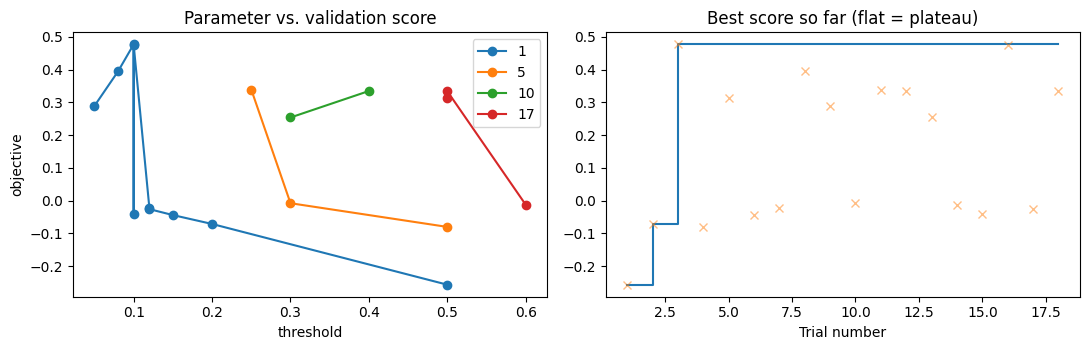

■ 試行回数: 18（目安 15 回以上） → OK
■ ベスト: trial#3 {'pos_weight': 1, 'threshold': 0.1, 'C': 1.0}  objective=0.4771
■ pos_weight: 4 種類を試した（範囲 1〜17）
■ threshold: 11 種類を試した（範囲 0.05〜0.6）
■ C: 4 種類を試した（範囲 0.01〜100）
■ 仮説を書いた試行: 18/18
■ 前半の最高 0.4771 → 後半の最高 0.4758


In [12]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
d = lab.df()
print("制約（Recall>=%.2f）を満たした設定の数: %d / %d" % (RECALL_TARGET, (d["recall"] >= RECALL_TARGET).sum(), len(d)))
display(d.drop(columns="hypothesis").sort_values("objective", ascending=False).head(8))
lab.plot(x="threshold", group="pos_weight", logx=False)    # threshold と objective、ベスト更新の推移
lab.report(min_trials=15)

In [13]:
# === 最終評価：探索を終えたら「1回だけ」実行する（2回目はエラー。テストを見て設定を変えるのはリーク）===
FINAL = dict(lab.best()["params"])   # 既定は objective 最良。選び直すなら下を書き換える（理由は解答欄へ）
# FINAL = {"pos_weight": 5, "threshold": 0.3, "C": 1.0}

final_model = LogisticRegression(max_iter=1000, C=FINAL["C"], class_weight={0: 1, 1: FINAL["pos_weight"]}).fit(X_train, y_train)
# ★あなたが書く★：テストデータの陽性確率を FINAL["threshold"] で 0/1 にして y_pred_test を作る（1〜2行）
#   ヒント: final_model.predict_proba(X_test)[:, 1] を閾値で比べて .astype(int)
y_pred_test = (final_model.predict_proba(X_test)[:, 1] >= FINAL["threshold"]).astype(int)

prec_t, rec_t = precision_score(y_test, y_pred_test, zero_division=0), recall_score(y_test, y_pred_test, zero_division=0)
lab.final_test(lambda: objective(prec_t, rec_t))
print(f"採用した設定: {FINAL}\nテストでの Precision={prec_t:.3f}  Recall={rec_t:.3f}  FN={confusion_matrix(y_test, y_pred_test)[1, 0]}")

最終テストスコア = 0.4444   （検証ベスト objective = 0.4771）
採用した設定: {'pos_weight': 1, 'threshold': 0.1, 'C': 1.0}
テストでの Precision=0.444  Recall=0.800  FN=11


In [14]:
# === ✍️ 問題2 解答（採点対象）===
import pandas as pd

# (2-a) 実験ログ（自動出力。15回以上・pos_weight と threshold の両方を動かすこと）
experiment_log = lab.df()
print(experiment_log.drop(columns="hypothesis").to_string())
lab.save()

# (2-b) 探索の進め方：各段階で何を見て次の試行を決めたか（試行番号 #n を引用）
answer_2_b = """
【#1〜#5】何もしない基準（#1: Precision 0.857 / Recall 0.543 / FN 101）から、閾値だけ（#2 0.2 → Recall 0.729、#3 0.1 → 0.801）と重みだけ（#4 w=5 → 0.719、#5 w=17 ≈ balanced → 0.819）を動かした。制約を満たしたのは #3（Precision 0.477）と #5（0.313）。
【#6〜#9】閾値だけの #3 が最良だったので、その周辺を細かく：0.15 → Recall 0.756、0.12 → 0.778（どちらも制約未達）、0.08 → 0.810（Precision 0.394）、0.05 → 0.837（0.289）。Precision を残せる境界は閾値 0.1 付近と分かった。
【#10〜#14】重みと閾値の組合せ：w=5・0.25（#11: 0.339）、w=10・0.4（#12: 0.335）、w=10・0.3（#13: 0.254）。制約を満たす組合せはどれも、閾値だけの #3・#8 より Precision が低かった。
【#15〜#18】C の影響：C=0.01（#15）は Recall 0.760 に下がり制約未達、C=100（#16）は #3 とほぼ同じ（0.476）。重み 17 なら C=0.01 でも 0.334（#18）。上位の構図が変わらないので終了した。
"""

# (2-c) 仮説が外れた試行を1つ以上取り上げ、なぜ外れたか・何を学んだか（#n を引用）
answer_2_c = """
仮説「閾値 0.2 で Recall 0.8 に届く」は外れた（#2: Recall 0.729）。陽性が 5.5% しかないと、ロジスティック回帰の予測確率は全体に低めに出るので、陽性のサンプルでも確率が 0.2 に届かないものが多い。届いたのは 0.1（#3）だった。
もう1つ、仮説「重みと閾値を組み合わせれば、片方だけより良くなる」も外れた（#11: 0.339、#12: 0.335 は、閾値だけの #3: 0.477、#8: 0.394 より低い）。重みを上げると、陽性の誤りを重く見るように係数そのものが学習し直されるため、陽性と陰性のスコアの並び方まで少し変わる。閾値だけを動かす方が、元のモデルのスコアの並び（Precision と Recall のバランス）をそのまま使える。
"""

# (2-d) 最良設定（pos_weight / threshold / C と objective, precision, recall）。制約を満たす設定の中で上位の差は意味があるか。最終的に採用した設定と理由
answer_2_d = """
最良は #3（pos_weight=1, threshold=0.1, C=1.0）：Precision 0.477 / Recall 0.801 / FN 44 で objective 0.4771。次点は #16（C=100, ほぼ同じ 0.476）、#8（閾値 0.08: 0.394）、#11（0.339）。#3 と #8 の差 0.08 は、陽性と判定した 370〜450 件程度の Precision の標準誤差（約 0.025）の 3 倍で、意味のある差と言える。
ただし #3 は Recall が 0.801 で、制約 0.80 の境界ぎりぎり（陽性 221 件中、あと 1 件見逃すと割る）。テストで Recall が少し下がると制約違反になる危険がある。安全を重視するなら、Recall に余裕のある #8（0.810）を選ぶ判断も十分あり得る。本解答では既定どおり #3 を採用し、テストでどうなるかを確かめた（2-e）。
"""

# (2-e) 最終テストの結果（Precision / Recall / FN）は探索時の値と比べてどうだったか。制約（Recall>=0.80）は守れていたか。差をどう解釈するか
answer_2_e = """
最終テストは Precision 0.444 / Recall 0.800 / FN 11（テストの陽性 55 件中 44 件を検出）で、objective 0.4444。制約は Recall ちょうど 0.800 で、ぎりぎり守れた。探索時（0.477 / 0.801）とほぼ同じだが、テストの陽性は 55 件しかなく、1 件で Recall が 0.018 動く（標準誤差は約 0.054）。あと 1 件見逃していたら 0.782 で制約違反だった。
解釈：境界ぎりぎりの設定は、データが変わると制約を割りやすい。実務で「Recall 0.8 以上」が絶対条件なら、検証で Recall 0.85 程度の余裕を持つ設定（#9: 閾値 0.05、Precision 0.289）を選び、Precision を少し犠牲にするのが安全。報告する性能はテストの値（Precision 0.44 / Recall 0.80）。
"""

# (2-f) 実験前の予測（prediction_2_*）と実際を比べる。どこがズレた？ 正しかった知識／間違っていた知識は？
answer_2_f = """
予測は「threshold の方が効く。最良は w=5, thr=0.2」。threshold の方が良いという予測は当たった（閾値だけの #3 が最良）。ズレたのは値で、0.2 では Recall 0.729（#2）と足りず、0.1 まで下げる必要があった。また w=5 との組合せ（#10, #11）は閾値だけより Precision が低かった。正しかった知識：閾値は再学習なしに直接 Recall を動かせる。間違っていた知識：陽性が少ないとき予測確率がどのくらい低く出るかの見積り（事前確率の影響）が甘かった。
"""

# (2-g) 考察1：何もしない設定の Recall・FN 件数。何を変えると Recall が上がり、Precision はどう動いたか
reflection1 = """
何もしない設定（w=1, thr=0.5, #1）は Precision 0.857 と高いが、Recall 0.543、FN 101 件（陽性 221 件中 120 件しか検出できず、半分近くを見逃す）。閾値を下げる（#2: 0.2 → Recall 0.729, FN 60, Precision 0.652）、重みを上げる（#5: w=17 → Recall 0.819, FN 40, Precision 0.313）と、Recall が上がり FN が減る一方、Precision は下がった。陽性の比率 0.055 と比べると、#3 の Precision 0.477 は約 9 倍で、「陽性と言った 2 件に 1 件は当たる」実用的な水準。
"""

# (2-h) 考察2：Recall↑ と Precision↓ のトレードオフが起きる理由（TP・FP・FN の動きに触れて）
reflection2 = """
閾値を下げる／少数クラスの重みを上げると、陽性と判定するサンプルが増える。本当の陽性のうち拾えるものが増えて TP が増え FN が減る（Recall = TP/(TP+FN) が上がる）が、同時に陰性（3779 件）の中から陽性と誤判定される FP も増える。陰性が圧倒的に多いので、FP の増え方が TP の増え方を上回り、Precision = TP/(TP+FP) が下がる。#1 → #3 で TP は 120 → 177 と 57 件増えたが、FP は約 20 → 約 194 件と 170 件以上増えた（Precision 0.857 → 0.477）。
"""

# (2-i) 考察3：pos_weight を上げる方法と threshold を下げる方法の比較（同じ Recall のときの Precision。#n を引用）
reflection3 = """
同じくらいの Recall で比べると、閾値を下げる方法の方が Precision が高かった。Recall ≈ 0.81 で、閾値だけ（#8: thr=0.08）は 0.394、重みだけ（#5: w=17）は 0.313、組合せ（#11: w=5・0.25、#12: w=10・0.4）は 0.335〜0.339。Recall ≈ 0.72 では、閾値だけ（#2）0.652 に対し重みだけ（#4）0.602。差は 0.05〜0.08 で、Precision の標準誤差（約 0.025）の 2〜3 倍あり、意味のある差と言える。どちらも陽性と判定する範囲を広げるが、重みは係数を学習し直すので陽性と陰性の並び方まで変わり、このデータでは少し不利だった。閾値は再学習不要な分だけ手軽でもある。
"""

# (2-j) 考察4：問題1で選んだ対処（A〜F）は、この目的に対して最良だったか
reflection4 = """
選んだ (C) 閾値を下げるは、この目的に対して最良だった（#3: Precision 0.477、重みの #5: 0.313 や組合せの #11: 0.339 より高い）。(B) class_weight="balanced"（#5）は「とりあえず不均衡対策」としてよく使われるが、制約を満たす中では Precision が 0.16 低く、閾値を適切に選ぶ方が良かった。ただし閾値 0.1 は Recall 0.801 と制約の境界ぎりぎりなので、実際に使うなら余裕を見て少し下げる（#8: 0.08）判断も必要。
"""


    trial  pos_weight  threshold       C  objective  precision  recall   fn
0       1           1       0.50    1.00    -0.2570      0.857   0.543  101
1       2           1       0.20    1.00    -0.0715      0.652   0.729   60
2       3           1       0.10    1.00     0.4771      0.477   0.801   44
3       4           5       0.50    1.00    -0.0805      0.602   0.719   62
4       5          17       0.50    1.00     0.3126      0.313   0.819   40
5       6           1       0.15    1.00    -0.0443      0.560   0.756   54
6       7           1       0.12    1.00    -0.0217      0.513   0.778   49
7       8           1       0.08    1.00     0.3943      0.394   0.810   42
8       9           1       0.05    1.00     0.2891      0.289   0.837   36
9      10           5       0.30    1.00    -0.0081      0.398   0.792   46
10     11           5       0.25    1.00     0.3390      0.339   0.819   40
11     12          10       0.40    1.00     0.3346      0.335   0.810   42
12     13   

## 問題3　ROC 曲線と AUC　【説明】
***

### ROC 曲線の読み方

ROC 曲線は「閾値を変化させたとき，どれだけ上手く分類できるか」を可視化する：

```
縦軸：真陽性率（TPR = 再現率）= TP / (TP + FN)
横軸：偽陽性率（FPR）= FP / (FP + TN)

・左上の角（TPR=1, FPR=0）が理想
・対角線（y=x）はランダムな予測（AUC=0.5）
```

**AUC の解釈**:
- ランダムに選んだ陽性サンプルのスコアが，ランダムに選んだ陰性サンプルのスコアより高い確率 = AUC

つまり AUC=0.9 なら，「陽性と陰性をランダムに1件ずつ選んだとき，モデルが陽性を高くスコアリングする確率が90%」という意味だ。

### class_weight なし vs あり の AUC 比較

今回は `class_weight="balanced"` のモデルの ROC 曲線を描く。AUC は**閾値を決めずに**「陽性を陰性より高くスコアできるか」を測るので，「全員陰性」と予測するだけで高く出てしまう正解率とは違い，不均衡データでも**モデル同士の比較**には使える。

ただし注意点が1つある。陰性（TN）が非常に多いと，偽陽性率 FPR = FP/(FP+TN) の分母が大きくなり，**FP がかなり多くても FPR は小さく見える**。そのため不均衡データでは AUC が「実際に使ったときの的中率（Precision）」より楽観的な印象を与えやすい。これを補うのが問題4の PR 曲線だ。

### 課題

下のコードセルは、`class_weight="balanced"` のモデルの **ROC 曲線**を描き、**AUC** を出すところまで **完成済み**です。今回はコードを書くのではなく、**ROC 曲線が何を表しているのかを読み解く**のが目的です。

各行の `# 説明:` の右に、その行が何をしているかを**自分の言葉で**書いてください（コードは変更しない）。書き終えたらセルを実行し、曲線と AUC が出ることを確認してください。

説明を書くときは、次の問いを意識してください：

- `predict_proba(...)[:, 1]` の `[:, 1]` はなぜ必要か？（何の確率を取り出しているか）
- ROC 曲線の**横軸 FPR**・**縦軸 TPR** はそれぞれ混同行列のどの値から計算されるか？（FPR = FP/(FP+TN)、TPR = TP/(TP+FN)）
- 対角線（点線）は何を表し、AUC=0.5 とはどういう状態か？
- AUC が「ランダムに選んだ陽性のスコアが、ランダムに選んだ陰性のスコアより高い確率」と等しいのはなぜ、直感的にどういう意味か？

> **考察**: ROC 曲線は閾値を 0〜1 まで動かしたときの (FPR, TPR) の軌跡です。問題2で「決定閾値を下げる」と Recall が上がったことと、ROC 曲線上を**どの向きに動くこと**が対応していますか？（TPR=Recall であることに注目）

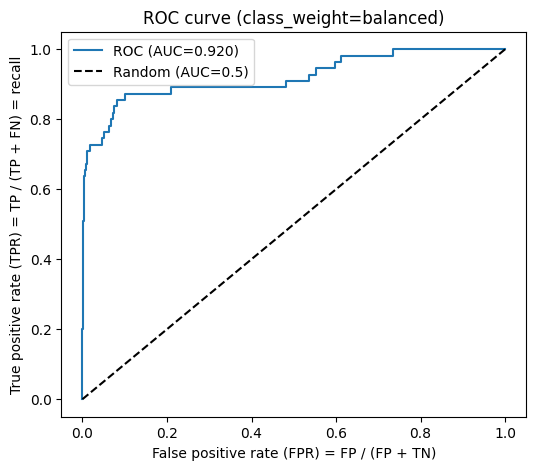

AUC = 0.9201


In [15]:
# 各行の # 説明: に自分の言葉で意味を書いてください（コードは変更しない）
# 説明は AI に書かせず、自分で書くこと

model = LogisticRegression(max_iter=1000, class_weight="balanced")  # 説明: 線形の分類モデル（ロジスティック回帰）を作る．class_weight="balanced" は，少数クラスの誤りの重みを大きくして（クラス比の逆数で）学習させる設定．max_iter は最適化の反復上限．
model.fit(X_train, y_train)                                         # 説明: 訓練データ（説明変数と 0/1 ラベル）でモデルの係数を学習する．
proba = model.predict_proba(X_test)[:, 1]                           # 説明: 各サンプルが各クラスに属する確率を (件数, 2) の配列で返す．[:, 1] は 2 列目＝クラス 1（陽性）の確率だけを取り出す．

fpr, tpr, thresholds = roc_curve(y_test, proba)                     # 説明: 閾値を 1 から 0 まで動かしたときの偽陽性率 fpr（陰性を誤って陽性とした割合 FP/(FP+TN)）と真陽性率 tpr（陽性を正しく見つけた割合 TP/(TP+FN)＝再現率）の並びと，そのときの閾値を返す．
roc_auc = auc(fpr, tpr)                                             # 説明: ROC 曲線の下の面積（Area Under the Curve）．1 が完璧，0.5 がランダム．陽性のスコアが陰性より高い確率に等しい．

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")               # 説明: 横軸に fpr，縦軸に tpr をとって ROC 曲線を描く．左上に膨らむほど良い．
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.5)")       # 説明: 対角線は，予測がランダム（スコアが陽性/陰性で同じ分布）のときの ROC．曲線がこれに近いほど識別能力が無く，AUC=0.5 に相当する．
plt.xlabel("False positive rate (FPR) = FP / (FP + TN)")
plt.ylabel("True positive rate (TPR) = TP / (TP + FN) = recall")
plt.title("ROC curve (class_weight=balanced)")
plt.legend()
plt.show()
print(f"AUC = {roc_auc:.4f}")


In [16]:
# === ✍️ 問題3 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (3-a) `predict_proba(...)[:, 1]` の `[:, 1]` で何を取り出しているか
answer_3_a = """
predict_proba は (件数, 2) の配列で、1 列目がクラス0の確率、2 列目がクラス1（陽性）の確率。[:, 1] は全行の 2 列目＝陽性である確率だけを取り出す。
"""

# (3-b) ROC の横軸 FPR・縦軸 TPR は混同行列のどの値から計算されるか
answer_3_b = """
FPR = FP / (FP + TN)：陰性のうち誤って陽性とした割合。TPR = TP / (TP + FN)：陽性のうち正しく見つけた割合（＝再現率）。どちらも混同行列の値から計算する。
"""

# (3-c) 対角線（点線）は何を表し、AUC=0.5 とはどういう状態か
answer_3_c = """
対角線は、予測がランダム（陽性と陰性でスコアの分布が同じ）のときの ROC。どの閾値でも TPR = FPR になる。AUC=0.5 は、ランダムに選んだ陽性のスコアが陰性のスコアより高い確率が 50%、つまりスコアが陽性/陰性を全く識別できない状態。
"""

# (3-d) 考察：閾値を下げて Recall を上げることは、ROC 曲線上をどの向きに動くことに対応するか
answer_3_d = """
閾値を下げると陽性判定が増え、TPR（Recall）が上がるが FPR も上がるので、ROC 曲線上を右上に移動する（閾値 1.0 は左下 (0,0)、閾値 0 は右上 (1,1)）。
"""



## 問題4　適合率-再現率曲線（PR曲線）　【説明+選択】
***

### なぜ不均衡データでは PR 曲線が重要か

不均衡データ（クラス0が95%）では ROC 曲線が「楽観的に見える」問題がある：

```
TN が非常に多い
→ FPR = FP / (FP + TN) が自動的に小さくなりやすい
→ ROC 曲線が左上に寄る
→ AUC が実際より高く見える
```

PR 曲線は TN を使わないため，少数クラス（クラス1）の検出性能をよりシビアに評価できる。

### PR 曲線の読み方

```
縦軸：適合率（Precision）= TP / (TP + FP)
横軸：再現率（Recall）  = TP / (TP + FN)

・右上（Precision=1, Recall=1）が理想
・曲線の下の面積（PR-AUC または Average Precision）が高いほど良い
・不均衡データでは PR-AUC のベースラインは「少数クラスの比率」（今回は0.05）
```

### 課題

下のコードセルは、問題3のモデルについて **PR 曲線**を描き、**PR-AUC（Average Precision）** とランダム基準（少数クラスの比率）を出すところまで **完成済み**です。問題3の `model` と `proba` をそのまま再利用します。

**(1) 説明**：各行の `# 説明:` の右に、その行が何をしているかを**自分の言葉で**書いてください（コードは変更しない）。特に、PR 曲線の**横軸 Recall・縦軸 Precision** がそれぞれ混同行列のどの値から計算されるか、ランダム基準がなぜ「少数クラスの比率」になるのかを意識してください。

**(2) 選択**：この**不均衡データ（クラス1が約5%）**でモデルを評価・報告するとき、**主指標として何を報告すべき**でしょうか。次から1つ選び、**理由**を解答用コードセルに書いてください。

> - **(A) Accuracy（正解率）**
> - **(B) ROC-AUC**
> - **(C) PR-AUC（Average Precision）**
> - **(D) 閾値0.5での F1 スコア**
> - **(E) 閾値0.5での Precision**
> - **(F) 「全部多数クラス」と予測したときの正解率との比較だけ**
>
> ヒント：不均衡データでは **TN が非常に多い** ため、`FPR = FP/(FP+TN)` が小さくなりやすく ROC 曲線は左上に寄って「楽観的」に見えます。一方 PR 曲線は **TN を使わない**ので少数クラスの検出をシビアに評価します。(A)(F) のように不均衡で誤解を招く指標も混ざっています。**なぜそれを主指標にするのか**、TN の多さに触れて説明してください。

> **考察**: 出力された **ROC の AUC** と **PR-AUC** の値を比べてください。どちらが高い値になりましたか？ その差は何を意味しますか？（同じモデルなのに2つの指標で値が違う理由）

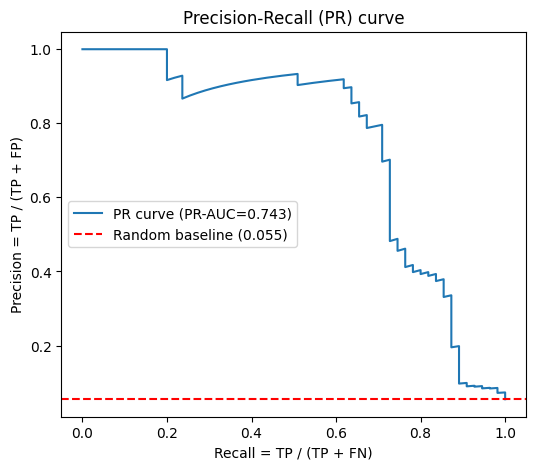

PR-AUC (Average Precision) = 0.7426
参考：ROC の AUC = 0.9201


In [17]:
# 各行の # 説明: に自分の言葉で意味を書いてください（コードは変更しない）
# 問題3の model・proba を再利用します

precision, recall, thresholds = precision_recall_curve(y_test, proba)  # 説明: 閾値を変えたときの適合率 precision と再現率 recall の配列，およびそのときの閾値の配列を返す（3つ）．precision と recall は閾値より 1 つ多い．
pr_auc = average_precision_score(y_test, proba)                        # 説明: PR 曲線の下の面積に相当する Average Precision（PR-AUC）．少数クラスの検出のしやすさを TN に依存せず評価する．
baseline = (y_test == 1).mean()                                        # 説明: 陽性（クラス1）の割合．全員を陽性と予測すると precision はこの割合になるので，これが「何も識別できないモデル」の PR 曲線の高さ（ランダム基準）になる．

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR curve (PR-AUC={pr_auc:.3f})")    # 説明: 横軸に再現率，縦軸に適合率をとって PR 曲線を描く．右上に寄るほど良い．
plt.axhline(baseline, color="red", linestyle="--",
            label=f"Random baseline ({baseline:.3f})")                    # 説明: 陽性の比率を水平線で引く．PR 曲線がこの線より上にあるほど，ランダムより識別できている．
plt.xlabel("Recall = TP / (TP + FN)")
plt.ylabel("Precision = TP / (TP + FP)")
plt.title("Precision-Recall (PR) curve")
plt.legend()
plt.show()
print(f"PR-AUC (Average Precision) = {pr_auc:.4f}")
print(f"参考：ROC の AUC = {roc_auc:.4f}")


In [18]:
# === ✍️ 問題4 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (4-a) PR 曲線のランダム基準がなぜ「少数クラスの比率」になるのか
answer_4_a = """
ランダム（何も識別できない）モデルは、陽性/陰性を無関係に予測するので、どの Recall でも Precision は陽性の割合に等しくなる（全員を陽性と予測すると Precision = 陽性の割合）。だから PR 曲線のランダム基準は、少数クラスの比率（この場合 0.055）の水平線になる。
"""

# (4-b) 選択：不均衡データで報告すべき主指標（A〜F）：(　)
# (A) Accuracy（正解率）
# (B) ROC-AUC
# (C) PR-AUC（Average Precision）
# (D) 閾値0.5での F1 スコア
# (E) 閾値0.5での Precision
# (F) 「全部多数クラス」と予測したときの正解率との比較だけ
answer_4_b = "C"
# (4-c) その理由（なぜ不均衡では PR の方が厳しい評価になるか。TN の多さに触れて）
answer_4_c = """
不均衡データでは陰性（TN）が圧倒的に多いため、FPR = FP/(FP+TN) は FP が多少増えても小さいまま（ROC 曲線は左上に寄って楽観的に見える）。PR 曲線の Precision = TP/(TP+FP) と Recall は TN を使わないので、少数クラスの検出精度をシビアに評価できる。(A) Accuracy は全員多数クラスでも 0.945 になり、(F) も同様に誤解を招く。だから PR-AUC を主指標にする。
"""

# (4-d) 考察：出力された ROC の AUC と PR-AUC の値の比較／差が意味すること
answer_4_d = """
ROC-AUC は 0.9201、PR-AUC は 0.7426 で、ROC の方が 0.18 高い。PR-AUC のランダム基準は少数クラスの比率（0.055）なので、0.7426 はランダムの約 13 倍で良い性能だが、ROC-AUC の 0.92 ほど「ほぼ完璧」ではない。問題2でも、Recall 0.8 を確保すると Precision は 0.48 程度にしかならなかった。ROC-AUC が高く見えるのは TN の多さで FPR が小さく出るため。同じモデルでも、少数クラスの検出という観点では ROC は楽観的で、PR の方が実態を反映する。
"""
# ROC の AUC：(　)
answer_4_roc_auc = "0.9201"
# PR-AUC：(　)
answer_4_pr_auc = "0.7426"
# 差が出る理由
answer_4_gap_reason = "陰性（TN）が非常に多いため、ROC の横軸 FPR = FP/(FP+TN) が小さく出て曲線が左上に寄り AUC が高く見える。PR は TN を使わず少数クラスの Precision に直接影響されるため、値が低く厳しい。"
